This notebook investigates results for different scenarios showing both the GNN estimates and cIM estimates.

In [1]:
import os
from pathlib import Path
import warnings

import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display, Markdown

import sim_ranking as sr
import ml_tools as mlt

In [2]:
n_obs_sites = 10

In [3]:
wdata = "/Users/claudy/dev/work/data"

results_dir = "/Users/claudy/dev/work/data/sim_ranking/results/gnn/1120_1125_cv_nzgmdb4p0_4_8_maxDist20_maxSites10_500epochs_sigmoid_nonlinearity_withAllTanh_2x31layers_L2Reg0p001_NoZx_DOut0p5"

In [4]:
# Injected Parameters
results_dir = "/home/claudy/dev/work/data/sim_ranking/results/gnn/hp_opt_test/1205_2114_cv_trial_26"
wdata = "/home/claudy/dev/work/data"


In [5]:
wdata = Path(wdata)
gnn_results_dir = Path(results_dir)
cim_results_dir = gnn_results_dir / "cim_results"
warnings.simplefilter(action='ignore', category=FutureWarning)

run_config = sr.ml.gnn_gm.RunConfig.from_yaml(gnn_results_dir / "run_config.yaml")

**Result Directory:** `{python} str(gnn_results_dir)`

In [6]:
# Load the combined validation results
gnn_val_results = pd.read_parquet(gnn_results_dir / "val_results.parquet").sort_index()

cim_val_results = None
if (cim_results_dir / "val_results.parquet").exists():
    cim_val_results = pd.read_parquet(cim_results_dir / "val_results.parquet").sort_index()

In [7]:
# Load observed data to get metadata
run_config = sr.ml.gnn_gm.RunConfig.from_yaml(gnn_results_dir / "run_config.yaml")
nzgmdb_ffp = wdata / run_config.rel_obs_data_ffp
obs_data = sr.data.load_obs_nzgmdb(nzgmdb_ffp)

In [8]:
# Distance matrix
dist_matrix = sr.utils.calculate_distance_matrix(obs_data.sites, obs_data.site_df)

In [9]:
# Load the empirical GMM predictions
emp_gmm_params = sr.data.load_emp_gmm_params( wdata / "sim_ranking/emp_gm_params/nzgmdb_v4p0" / "emp_gm_params.parquet" )
emp_gmm_pSA_mean_keys = [f"pSA_{cur_period}_mean" for cur_period in sr.constants.PERIODS]
emp_gmm_pSA_std_keys = [f"pSA_{cur_period}_std_Total" for cur_period in sr.constants.PERIODS]

In [10]:
def get_obs_sites(event: str, int_site: str, gnn_val_results: pd.DataFrame, dist_matrix: pd.DataFrame, n_obs_sites: int = 5):
    cur_id = f"{event}_{int_site}"
    obs_sites = (
        dist_matrix.loc[cur_site]
        .loc[gnn_val_results.loc[cur_id].obs_sites.astype(str)]
        .sort_values()
        .index.values.astype(str)
    )[:n_obs_sites]
    
    return obs_sites

def exp_formatter(y, pos):
    return f'{np.exp(y):.4f}'
    # return f"{np.exp(y):.2e}"

def plot_gnn_cim(ax: plt.Axes, cur_id: str, gnn_results: pd.DataFrame, cim_results: pd.DataFrame = None, emp_gmm_params: pd.DataFrame = None, log_values: bool = False):
    
    # Empirical GMM
    if emp_gmm_params is not None:
        cur_emp_gmm_mean = emp_gmm_params.loc[cur_id, emp_gmm_pSA_mean_keys].values.astype(float)
        cur_emp_gmm_std = emp_gmm_params.loc[cur_id, emp_gmm_pSA_std_keys].values.astype(float)
        ax.plot(sr.constants.PERIODS, cur_emp_gmm_mean if log_values else np.exp(cur_emp_gmm_mean), label="Empirical GMM", c="gray")
        ax.plot(sr.constants.PERIODS, cur_emp_gmm_mean + cur_emp_gmm_std if log_values else np.exp(cur_emp_gmm_mean + cur_emp_gmm_std), c="gray", linestyle="--")
        ax.plot(sr.constants.PERIODS, cur_emp_gmm_mean - cur_emp_gmm_std if log_values else np.exp(cur_emp_gmm_mean - cur_emp_gmm_std), c="gray", linestyle="--")
    
    # CIM
    if cim_results is not None:
        cur_cim_mean = cim_results.loc[cur_id, sr.constants.CIM_PRED_PSA_KEYS].values.astype(float)
        cur_cim_std = cim_results.loc[cur_id, sr.constants.CIM_PRED_STD_PSA_KEYS].values.astype(float)
        ax.plot(sr.constants.PERIODS, cur_cim_mean if log_values else np.exp(cur_cim_mean), label="cIM", c="g")
        ax.plot(sr.constants.PERIODS, cur_cim_mean + cur_cim_std if log_values else np.exp(cur_cim_mean + cur_cim_std), c="g", linestyle="--")
        ax.plot(sr.constants.PERIODS, cur_cim_mean - cur_cim_std if log_values else np.exp(cur_cim_mean - cur_cim_std), c="g", linestyle="--")
        
    # GNN
    cur_gnn_mean = gnn_results.loc[cur_id, sr.constants.GNN_PRED_PSA_KEYS].values.astype(float)
    cur_gnn_std = gnn_results.loc[cur_id, sr.constants.GNN_PRED_STD_PSA_KEYS].values.astype(float)
    ax.plot(sr.constants.PERIODS, cur_gnn_mean if log_values else np.exp(cur_gnn_mean), label="GNN", c="b")
    ax.plot(sr.constants.PERIODS, cur_gnn_mean + cur_gnn_std if log_values else np.exp(cur_gnn_mean + cur_gnn_std), c="b", linestyle="--")
    ax.plot(sr.constants.PERIODS,  cur_gnn_mean - cur_gnn_std if log_values else np.exp(cur_gnn_mean - cur_gnn_std), c="b", linestyle="--")
        
    # Observed
    obs_values = gnn_results.loc[cur_id, sr.constants.PSA_KEYS].values.astype(float) 
    ax.plot(sr.constants.PERIODS, 
        obs_values if log_values else np.exp(obs_values), 
        label="Observed", c="r")
    
    
        
    ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
    
    if log_values:
        ax.yaxis.set_major_formatter(FuncFormatter(exp_formatter))
        
    ax.set_xscale("log")
    ax.set_xlim(0.01, 10)
    ax.set_xlabel("Period (s)")
    
    # Get smallest/largest y-values
    min_y = min([min(line.get_ydata()) for line in ax.get_lines()])
    max_y = max([max(line.get_ydata()) for line in ax.get_lines()])
    if log_values:
        return np.exp(min_y), np.exp(max_y)
    return min_y, max_y
    
def plot_obs_sites(ax: plt.Axes, event: str, int_site: str, obs_sites: np.ndarray[str], obs_data: sr.ObservedData, dist_matrix: pd.DataFrame, log_values: bool = False):
    # cur_id = f"{event}_{int_site}"

    cur_obs_sites_dist = dist_matrix.loc[int_site].loc[obs_sites]
    cur_obs_data = obs_data.get_event_data(event, obs_sites)
    
    for int_site in obs_sites:
        cur_values = cur_obs_data.loc[int_site, sr.constants.PSA_KEYS].values.astype(float)
        ax.plot(sr.constants.PERIODS, np.log(cur_values) if log_values else cur_values, label=f"{int_site}, {cur_obs_sites_dist[int_site]:.2f} km")
    
    ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")    
    
    if log_values:
        ax.yaxis.set_major_formatter(FuncFormatter(exp_formatter))
        
    ax.set_xscale("log")
    ax.set_xlim(0.01, 10)
    ax.set_xlabel("Period (s)")
    
    # Get smallest/largest y-values
    min_y = min([min(line.get_ydata()) for line in ax.get_lines()])
    max_y = max([max(line.get_ydata()) for line in ax.get_lines()])
    if log_values:
        return np.exp(min_y), np.exp(max_y)
    return min_y, max_y

In [11]:
def create_4plot(event: str, int_site: str, obs_sites: np.ndarray[str], gnn_val_results: pd.DataFrame, cim_val_results: pd.DataFrame, obs_data: sr.ObservedData, dist_matrix: pd.DataFrame, emp_gmm_params: pd.DataFrame = None):
    cur_id = f"{event}_{int_site}"
    
    fig, (ax1, ax2, ax3, ax4) = mlt.plotting.get_fig_axes(4, 2, 2, ind_figsize=(8, 6))
    
    min_y1, max_y1 = plot_gnn_cim(ax1, cur_id, gnn_val_results, cim_val_results, emp_gmm_params)
    ax1.legend()
    
    min_y2, max_y2 = plot_gnn_cim(ax2, cur_id, gnn_val_results, cim_val_results, log_values=True, emp_gmm_params=emp_gmm_params)
    ax2.set_ylim(None, np.log(ax1.get_ylim()[1]))
    
    min_y3, max_y3 = plot_obs_sites(ax3, event, int_site, obs_sites, obs_data, dist_matrix)
    ax3.legend()
    # ax3.set_ylim(None, np.log(ax1.get_ylim()[1]))
    
    min_y4, max_y4 = plot_obs_sites(ax4, event, int_site, obs_sites, obs_data, dist_matrix, log_values=True)
    
    # y-axis limits
    min_y = min(min_y1, min_y2, min_y3, min_y4)
    max_y = max(max_y1, max_y2, max_y3, max_y4)
    
    ax1.set_ylim(min_y, max_y)
    ax2.set_ylim(np.log(min_y), np.log(max_y))
    ax3.set_ylim(min_y, max_y)
    ax4.set_ylim(np.log(min_y), np.log(max_y))
    
    fig.tight_layout()

In [12]:
def create_2plot_log(event: str, int_site: str, obs_sites: np.ndarray[str], gnn_val_results: pd.DataFrame, cim_val_results: pd.DataFrame, obs_data: sr.ObservedData, dist_matrix: pd.DataFrame, emp_gmm_params: pd.DataFrame = None):
    cur_id = f"{event}_{int_site}"
    
    fig, (ax1, ax2) = mlt.plotting.get_fig_axes(2, 2, 1, ind_figsize=(8, 6))
    
    min_y2, max_y2 = plot_gnn_cim(ax1, cur_id, gnn_val_results, cim_val_results, log_values=True, emp_gmm_params=emp_gmm_params)
    ax1.legend()
    
    min_y4, max_y4 = plot_obs_sites(ax2, event, int_site, obs_sites, obs_data, dist_matrix, log_values=True)
    ax2.legend()
    
    # y-axis limits
    min_y = min(min_y2, min_y4)
    max_y = max(max_y2, max_y4)
    ax1.set_ylim(np.log(min_y), np.log(max_y))
    ax2.set_ylim(np.log(min_y), np.log(max_y))
    
    fig.tight_layout()

In [13]:
def get_site_info_df(event: str, int_site: str, obs_sites: np.ndarray[str], obs_data: sr.ObservedData, dist_matrix: pd.DataFrame):
    site_cols = ["rrup", "vs30", "z1p0", "z2p5", "tsite"]
    site_info_sites = [int_site] + cur_obs_sites.tolist()
    site_info_records = mlt.array_utils.numpy_str_join("_", event, site_info_sites)
    
    site_info_df = obs_data.record_df.loc[site_info_records, site_cols].copy()
    site_info_df["site_int_distance"] = (
        dist_matrix.loc[int_site].loc[site_info_sites].values
    )
    
    return site_info_df

### 2016p858000 - HSSS
Observed GM at the SoI is significantly smaller than any nearby observations.
**Any way for a model to pick this up?** The closest site (wrt. observed GM) is the one that is furthest away from the site, and none of the other properties (vs30, z1.0, etc) match either).

In [14]:
cur_event = "2016p858000"
cur_site = "HSSS"

if f"{cur_event}_{cur_site}" in gnn_val_results.index:
	# Plots
	cur_obs_sites = get_obs_sites(cur_event, cur_site, gnn_val_results, dist_matrix, n_obs_sites=n_obs_sites)
	# create_4plot(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix)
	create_2plot_log(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix, emp_gmm_params=emp_gmm_params)

	# Info
	site_info_df = get_site_info_df(cur_event, cur_site, cur_obs_sites, obs_data, dist_matrix)
	display(site_info_df)
else:
    print(f"No results for {cur_event}_{cur_site}")

No results for 2016p858000_HSSS


### 3528839 - HPSC

,rrup,vs30,z1p0,z2p5,tsite,site_int_distance
3528839_HPSC,2.677783,194.0,645.0,2.225,5.24,0.000000
3528839_NNBS,1.801775,204.0,685.0,2.175,4.87,1.448471
3528839_NBLC,0.512372,189.0,605.0,2.025,3.75,2.426769
3528839_PRPC,4.556719,196.0,485.0,2.075,5.28,3.120815
3528839_SHLC,5.552238,201.0,675.0,2.475,4.96,3.160961
3528839_REHS,7.826678,155.0,645.0,2.575,4.99,5.868689
3528839_CHHC,8.777697,196.0,515.0,2.175,2.66,7.138936
3528839_PPHS,9.946331,180.0,665.0,3.325,6.20,7.754829
3528839_PARS,1.221945,750.0,58.0,1.775,0.05,8.357180
3528839_HVSC,4.465651,348.0,19.0,1.525,0.27,8.726144


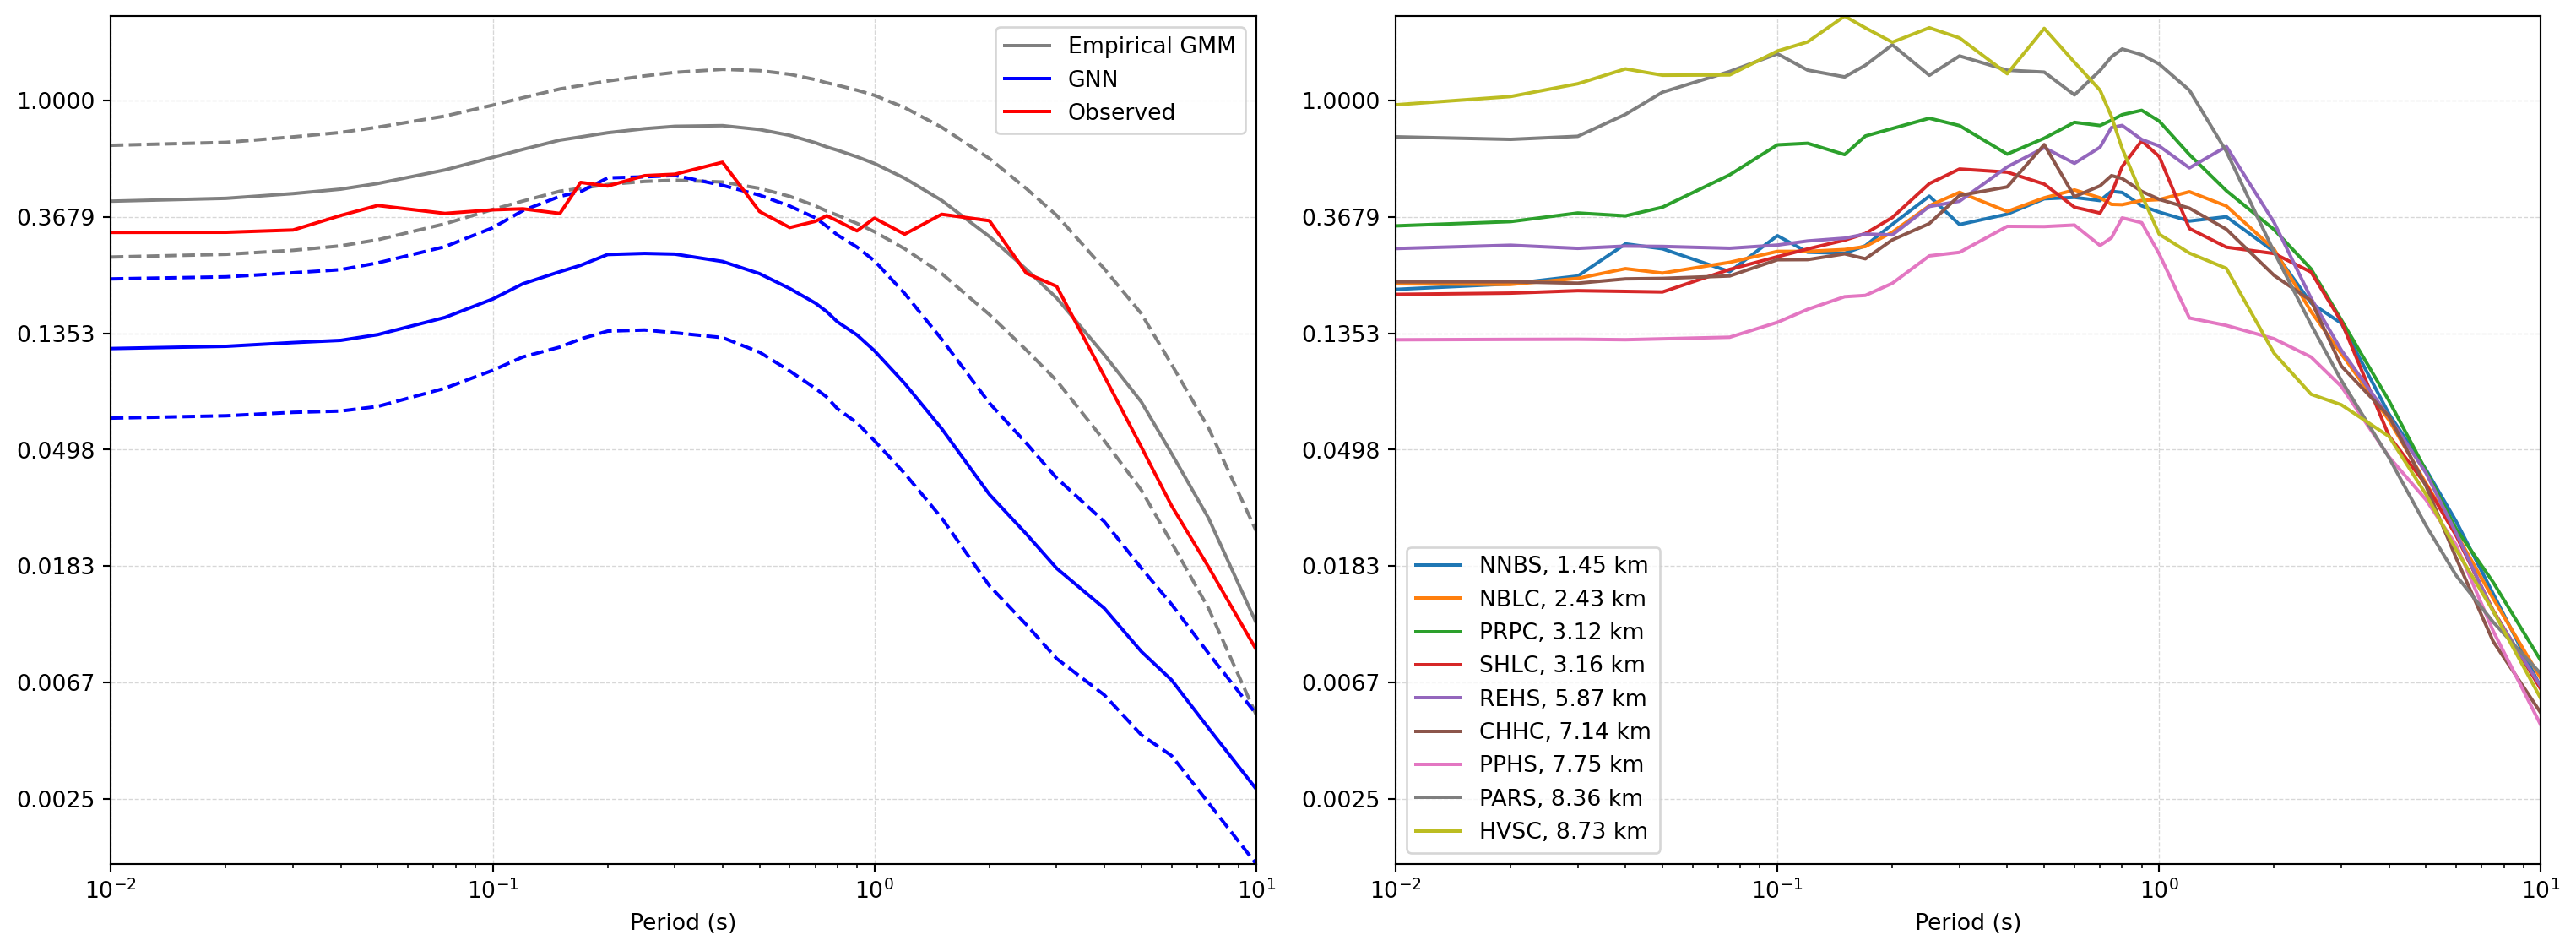

In [15]:
cur_event = "3528839"
cur_site = "HPSC"

if f"{cur_event}_{cur_site}" in gnn_val_results.index:
	# Plots
	cur_obs_sites = get_obs_sites(cur_event, cur_site, gnn_val_results, dist_matrix, n_obs_sites=n_obs_sites)
	# create_4plot(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix)
	create_2plot_log(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix, emp_gmm_params=emp_gmm_params)

	# Info
	site_info_df = get_site_info_df(cur_event, cur_site, cur_obs_sites, obs_data, dist_matrix)
	display(site_info_df)
else:
    print(f"No results for {cur_event}_{cur_site}")

### 2016p858000 - LRSS
Observed (at SoI) follows observed from one nearby observation site, completely different from all others. No clear property match.
**Any way for the model to pick this up?**

In [16]:
cur_event = "2016p858000"
cur_site = "LRSS"

if f"{cur_event}_{cur_site}" in gnn_val_results.index:
	# Plots
	cur_obs_sites = get_obs_sites(cur_event, cur_site, gnn_val_results, dist_matrix, n_obs_sites=n_obs_sites)
	# create_4plot(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix)
	create_2plot_log(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix, emp_gmm_params=emp_gmm_params)

	# Info
	site_info_df = get_site_info_df(cur_event, cur_site, cur_obs_sites, obs_data, dist_matrix)
	display(site_info_df)
else:
    print(f"No results for {cur_event}_{cur_site}")

No results for 2016p858000_LRSS


### 2839343 - NSPS

Example of an observation site extremely close to the SoI, and almost identical GMs.

,rrup,vs30,z1p0,z2p5,tsite,site_int_distance
2839343_NSPS,145.89550,600.0,54.0,6.625,0.186,0.000000
2839343_NAMS,145.61267,243.0,68.0,6.625,0.340,0.292584
2839343_NGHS,145.80536,440.0,61.0,6.675,0.187,0.421936
2839343_NCHS,148.14630,230.0,133.0,6.525,0.865,2.509089
2839343_NCDS,149.30951,176.0,118.0,6.475,1.100,3.624456
2839343_HCDS,159.34662,196.0,97.0,5.125,3.320,18.486803


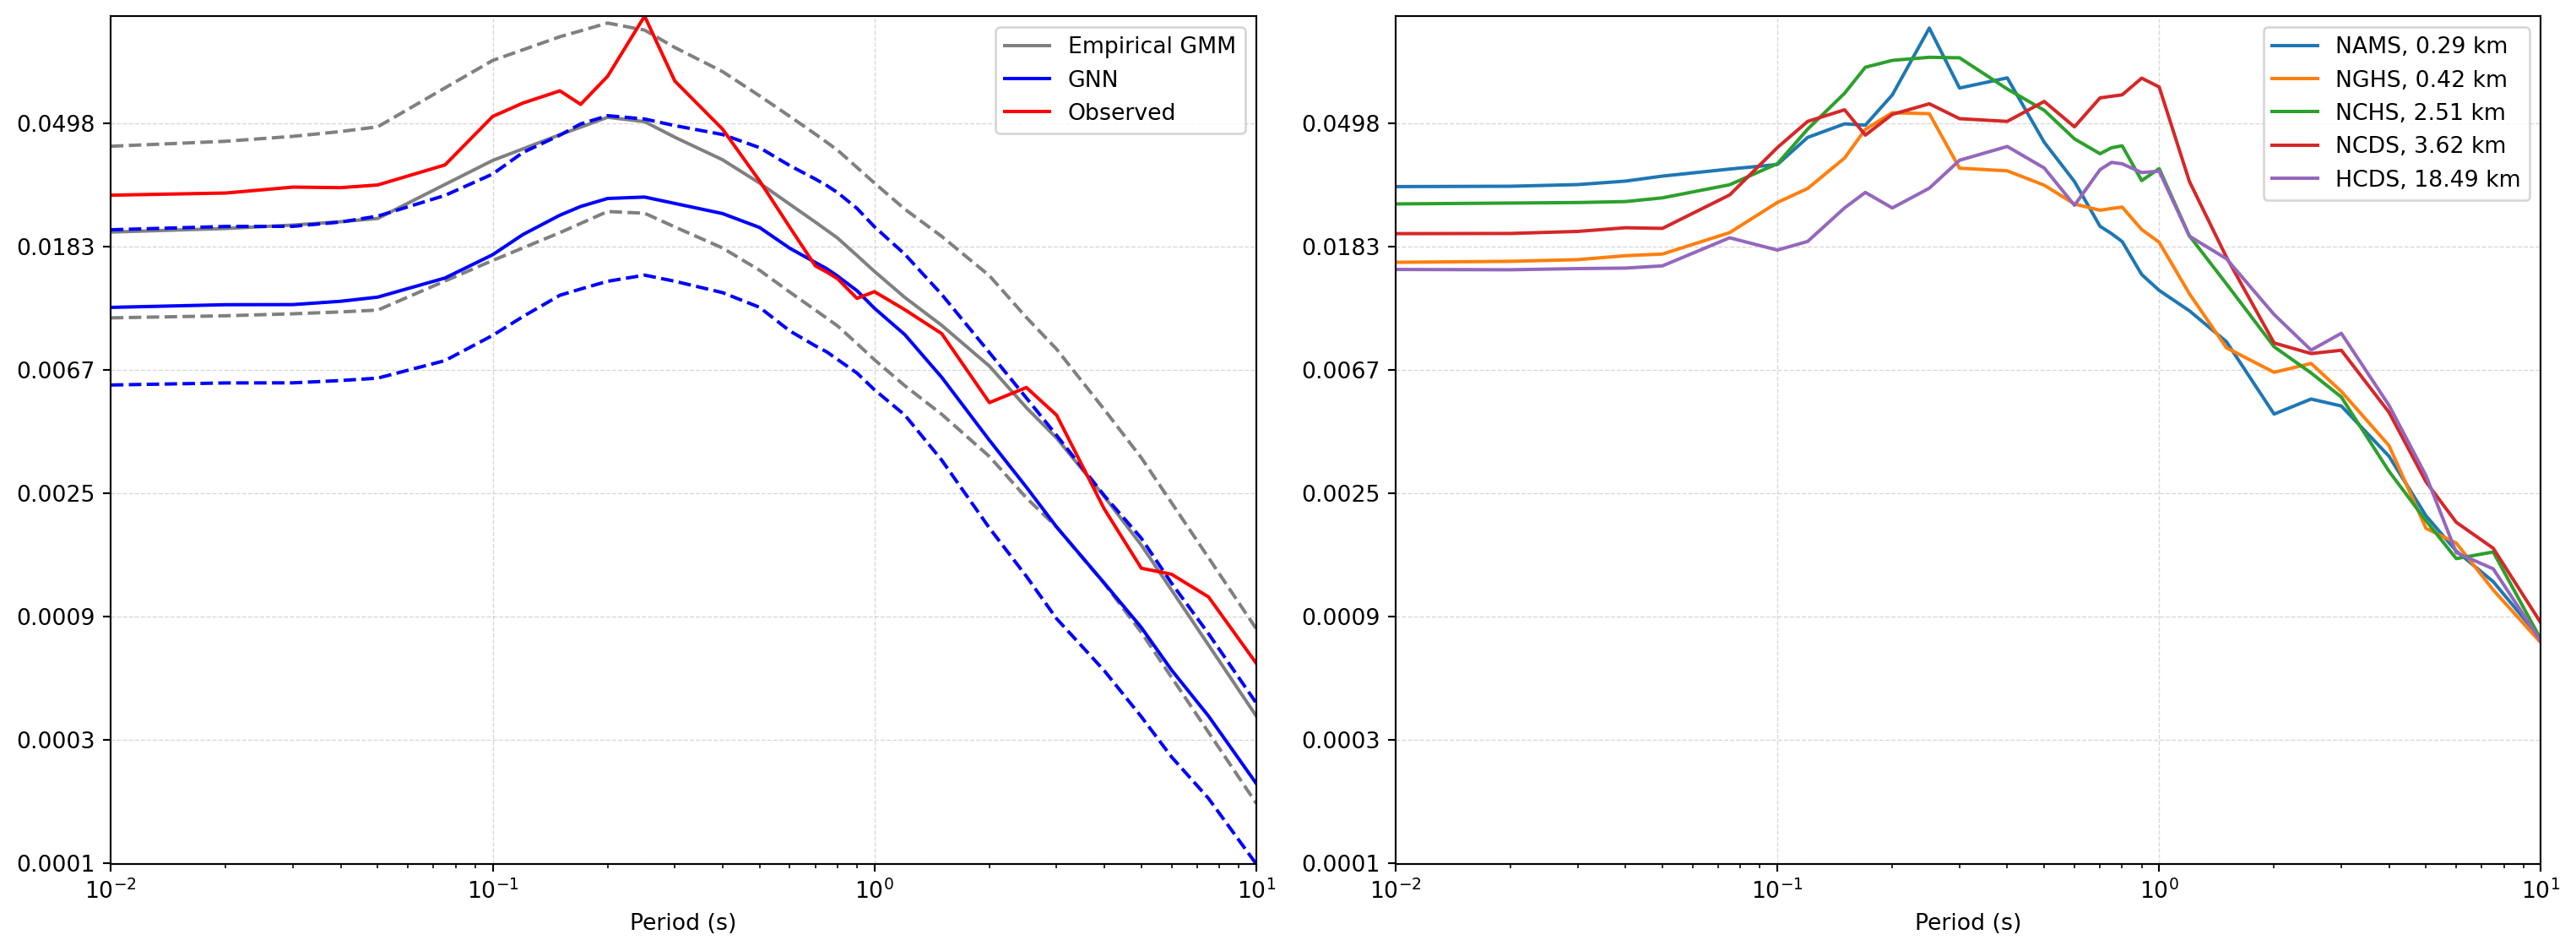

In [17]:
cur_event = "2839343"
cur_site = "NSPS"

if f"{cur_event}_{cur_site}" in gnn_val_results.index:
	# Plots
	cur_obs_sites = get_obs_sites(cur_event, cur_site, gnn_val_results, dist_matrix, n_obs_sites=n_obs_sites)
	# create_4plot(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix)
	create_2plot_log(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix, emp_gmm_params=emp_gmm_params)

	# Info
	site_info_df = get_site_info_df(cur_event, cur_site, cur_obs_sites, obs_data, dist_matrix)
	display(site_info_df)
else:
    print(f"No results for {cur_event}_{cur_site}")